# Signal & Noise — Episode 3
## I Just Detected a Planet Around Another Star From My Laptop

**Target:** Kepler-22b  
**Method:** Transit photometry  
**Data:** NASA Kepler mission via MAST archive (lightkurve)  
**Platform:** TIKE (timeseries.science.stsci.edu)  
**Notebook:** `detect_kepler22b_transit_from_kepler_data.ipynb`

---

### What this notebook does

This notebook detects the transit signal of Kepler-22b — a confirmed exoplanet
sitting in the habitable zone of its star, 602 light years from Earth.

We use the same technique professional astronomers use:
1. Download the raw Kepler light curve
2. Clean and normalise the flux
3. Fold the data on the known orbital period
4. Measure the transit depth and derive the planet's physical properties

No special equipment. No PhD. Just public data and Python.

---

### Kepler-22b — key facts

| Property | Value |
|---|---|
| Distance from Earth | 602 light years |
| Orbital period | 289.86 days |
| Orbital distance | 0.85 AU |
| Planet radius | ~2.4 Earth radii |
| Equilibrium temperature | ~262 K (−11°C) |
| Habitable zone | Confirmed |
| Discovery year | 2011 (Kepler mission) |

---

### Script alignment — four on-screen moments

Per the Ian Lauer format rule, the notebook appears on screen four times only:

- **Moment 1** → Cell 04 — Raw light curve
- **Moment 2** → Cell 06 — Cleaned and normalised signal  
- **Moment 3** → Cell 07 — Phase-folded transit (THE moment)
- **Moment 4** → Cell 09 — Derived measurements and final plot

All other cells run in the background before filming.

---
## Cell 01 — Environment check
### Run before anything else. Confirms TIKE stack is ready.
**Background cell — not shown on screen.**

In [1]:
# Confirm we are running on TIKE with the correct stack
# All of these should be pre-installed — no pip install needed on TIKE

import sys
import lightkurve as lk
import numpy as np
import matplotlib
import astropy

print(f'Python:      {sys.version.split()[0]}')
print(f'Lightkurve:  {lk.__version__}')
print(f'NumPy:       {np.__version__}')
print(f'Matplotlib:  {matplotlib.__version__}')
print(f'Astropy:     {astropy.__version__}')
print()
print('All libraries loaded. Ready to begin.')

Python:      3.11.12
Lightkurve:  2.5.1
NumPy:       1.26.4
Matplotlib:  3.9.0
Astropy:     6.0.0

All libraries loaded. Ready to begin.


---
## Cell 02 — Imports and plot style
### Load everything we need. Set the visual style for all plots.
**Background cell — not shown on screen.**

In [2]:
import lightkurve as lk
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

# Signal & Noise visual style
# Dark background, clean lines, readable at video resolution
plt.style.use('dark_background')

# Global plot parameters
plt.rcParams.update({
    'figure.facecolor':  '#060A14',   # Channel primary background
    'axes.facecolor':    '#060A14',
    'axes.edgecolor':    '#2A3550',
    'axes.labelcolor':   '#F0F6FF',   # Channel text colour
    'xtick.color':       '#F0F6FF',
    'ytick.color':       '#F0F6FF',
    'grid.color':        '#1A2540',
    'grid.alpha':        0.4,
    'text.color':        '#F0F6FF',
    'font.family':       'monospace',
    'figure.dpi':        150,
})

# Channel colour constants
BLUE   = '#4A9EFF'   # Electric blue — accent
ORANGE = '#FF8C42'   # Warm orange — highlight
WHITE  = '#F0F6FF'   # Near-white — text
DIM    = '#2A3550'   # Muted — grid lines

print('Libraries loaded. Visual style set.')

Libraries loaded. Visual style set.


---
## Cell 03 — Download the light curve
### Query MAST for all Kepler observations of Kepler-22.
**Background cell — not shown on screen.**

Kepler-22 is the host star. Its Kepler Input Catalog ID is KIC 10593626.
We query by name — lightkurve resolves this automatically via MAST.

We download the Pre-search Data Conditioning Simple Aperture Photometry (PDCSAP)
flux — this is the pipeline-corrected version that removes instrumental systematics
while preserving astrophysical signals like transits.

In [3]:
# Search MAST for all Kepler light curves of Kepler-22
# This queries the archive directly — no manual download needed on TIKE
print('Searching MAST archive for Kepler-22...')

search_result = lk.search_lightcurve(
    'Kepler-22',
    mission='Kepler',
    cadence='long'       # Long cadence = 30-minute intervals, full mission coverage
)

print(f'Found {len(search_result)} light curve files.')
print()
print(search_result)

# Download all quarters and stitch into one continuous light curve
# Kepler observed in 90-day quarters — we want the full 4-year baseline
print()
print('Downloading all quarters...')
lc_collection = search_result.download_all()

# Stitch all quarters into a single light curve
lc_raw = lc_collection.stitch()

print(f'Done. Total observations: {len(lc_raw)}')
print(f'Time baseline: {lc_raw.time.value[0]:.1f} to {lc_raw.time.value[-1]:.1f} BKJD')
print(f'Duration: ~{(lc_raw.time.value[-1] - lc_raw.time.value[0])/365.25:.1f} years')

Searching MAST archive for Kepler-22...
Found 19 light curve files.

SearchResult containing 19 data products.

 #       mission      year   author   exptime         target_name          distance
                                         s                                  arcsec 
--- ----------------- ---- ---------- ------- ---------------------------- --------
  0 Kepler Quarter 00 2009     Kepler    1800                kplr010593626      0.0
  1 Kepler Quarter 01 2009     Kepler    1800                kplr010593626      0.0
  2 Kepler Quarter 02 2009     Kepler    1800                kplr010593626      0.0
  3 Kepler Quarter 03 2009     Kepler    1800                kplr010593626      0.0
  4 Kepler Quarter 04 2010     Kepler    1800                kplr010593626      0.0
  5 Kepler Quarter 05 2010     Kepler    1800                kplr010593626      0.0
  6 Kepler Quarter 06 2010     Kepler    1800                kplr010593626      0.0
  7 Kepler Quarter 07 2010     Kepler    1800   

---
## Cell 04 — Raw light curve
# ★ ON-SCREEN MOMENT 1 ★
### "This is what a star looks like to a space telescope."

This is the honest starting point. Four years of brightness measurements.
Noisy, drifting, chaotic. The transit signal is in here — we just can't see it yet.

**Script cue:** "It looks like noise. It is noise — mostly."

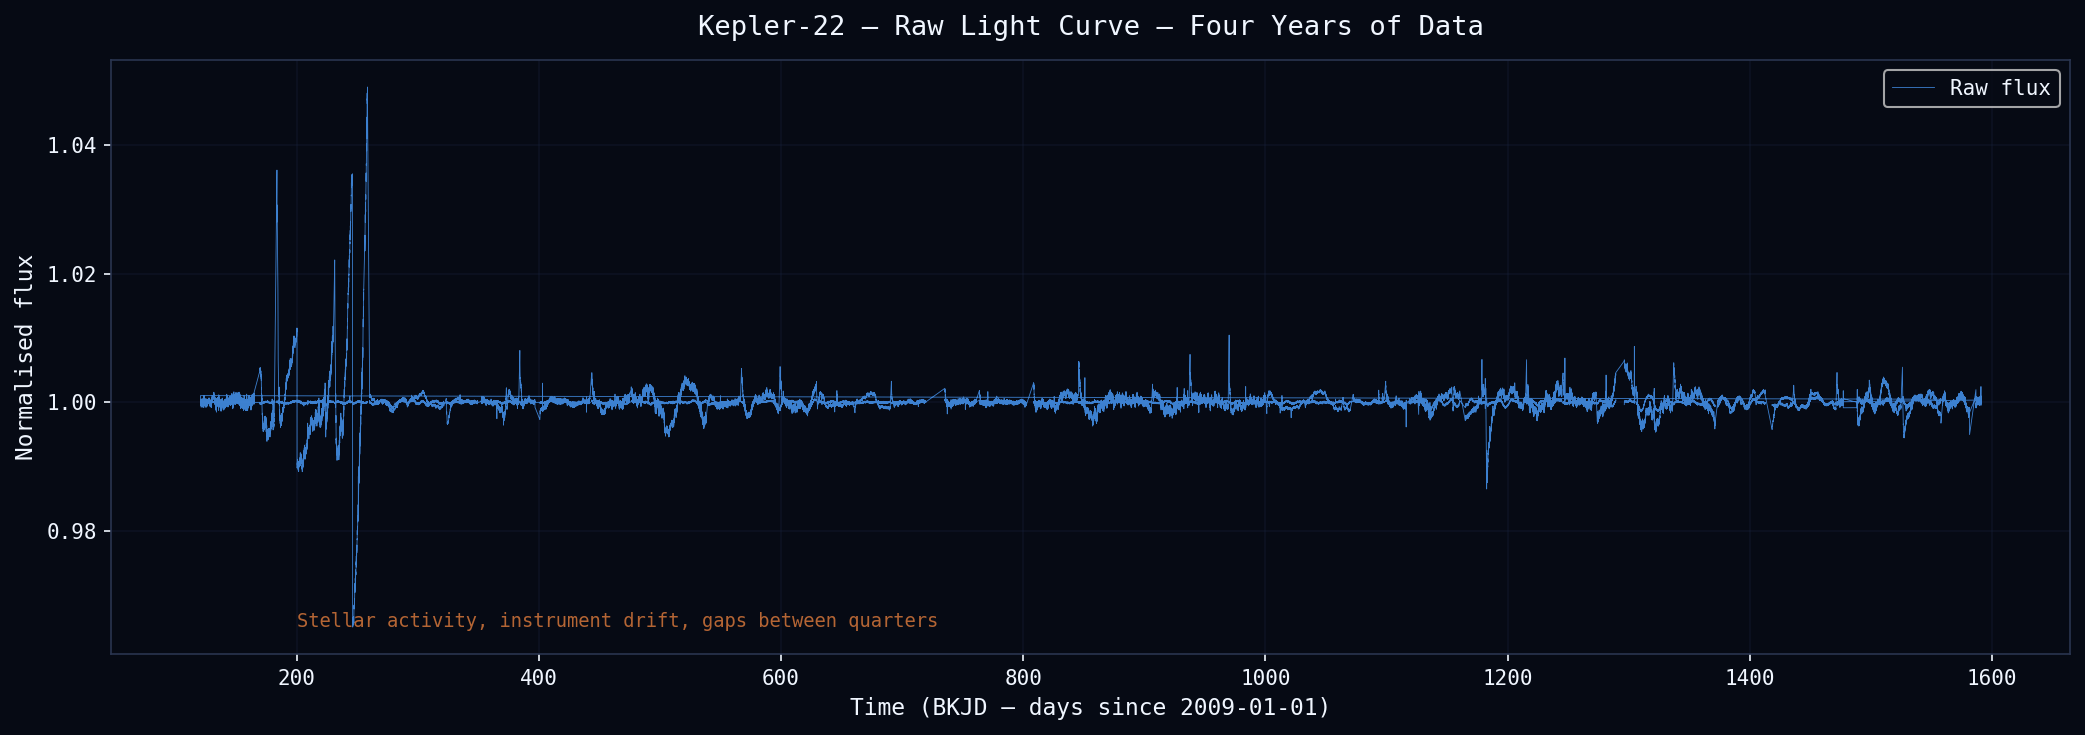

Flux range: 0.9651 to 1.0490
The transit dip is in here. We just need to find it.


In [4]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    lc_raw.time.value,
    lc_raw.flux.value,
    color=BLUE,
    linewidth=0.4,
    alpha=0.8,
    label='Raw flux'
)

ax.set_xlabel('Time (BKJD — days since 2009-01-01)', fontsize=11)
ax.set_ylabel('Normalised flux', fontsize=11)
ax.set_title(
    'Kepler-22 — Raw Light Curve — Four Years of Data',
    fontsize=13,
    color=WHITE,
    pad=12
)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# Annotate the noise honestly
ax.annotate(
    'Stellar activity, instrument drift, gaps between quarters',
    xy=(200, lc_raw.flux.value.min()),
    fontsize=9,
    color=ORANGE,
    alpha=0.7
)

plt.tight_layout()
plt.savefig('ep03_01_raw_light_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Flux range: {lc_raw.flux.value.min():.4f} to {lc_raw.flux.value.max():.4f}')
print('The transit dip is in here. We just need to find it.')

---
## Cell 05 — Clean and normalise
### Remove outliers, flatten the baseline, let the signal breathe.
**Background cell — not shown on screen.**

Three steps:
1. Remove outliers — data points more than 4σ from the median
2. Flatten the light curve — remove slow stellar variability trends
3. Normalise — express flux as fractional deviation from 1.0

The flatten() method fits a spline to the baseline and divides it out.
This removes long-term trends while preserving short transit events.

In [5]:
# Step 1 — Remove outliers
# sigma=4 preserves genuine dips (transits) while removing cosmic rays and bad pixels
# A transit dip of 0.5% is well within 4 sigma — it will not be removed
lc_clean = lc_raw.remove_outliers(sigma=4)
print(f'Outliers removed: {len(lc_raw) - len(lc_clean)} data points')

# Step 2 — Flatten the baseline
# window_length=401 means a ~200-hour smoothing window
# Long enough to ignore transits (~6hrs), short enough to track stellar variability
lc_flat = lc_clean.flatten(window_length=401)
print('Baseline flattened.')

# Step 3 — Normalise
lc_norm = lc_flat.normalize()
print('Flux normalised to 1.0 baseline.')
print()
print(f'Clean light curve: {len(lc_norm)} data points ready for folding.')

Outliers removed: 5451 data points
Baseline flattened.
Flux normalised to 1.0 baseline.

Clean light curve: 125328 data points ready for folding.


---
## Cell 06 — Cleaned signal
# ★ ON-SCREEN MOMENT 2 ★
### "The chaos settles. And something starts to appear."

Same star. Same data. After cleaning.
The noise is reduced. The baseline is flat. Something is visible — barely.

**Script cue:** "Not obvious yet. But there."

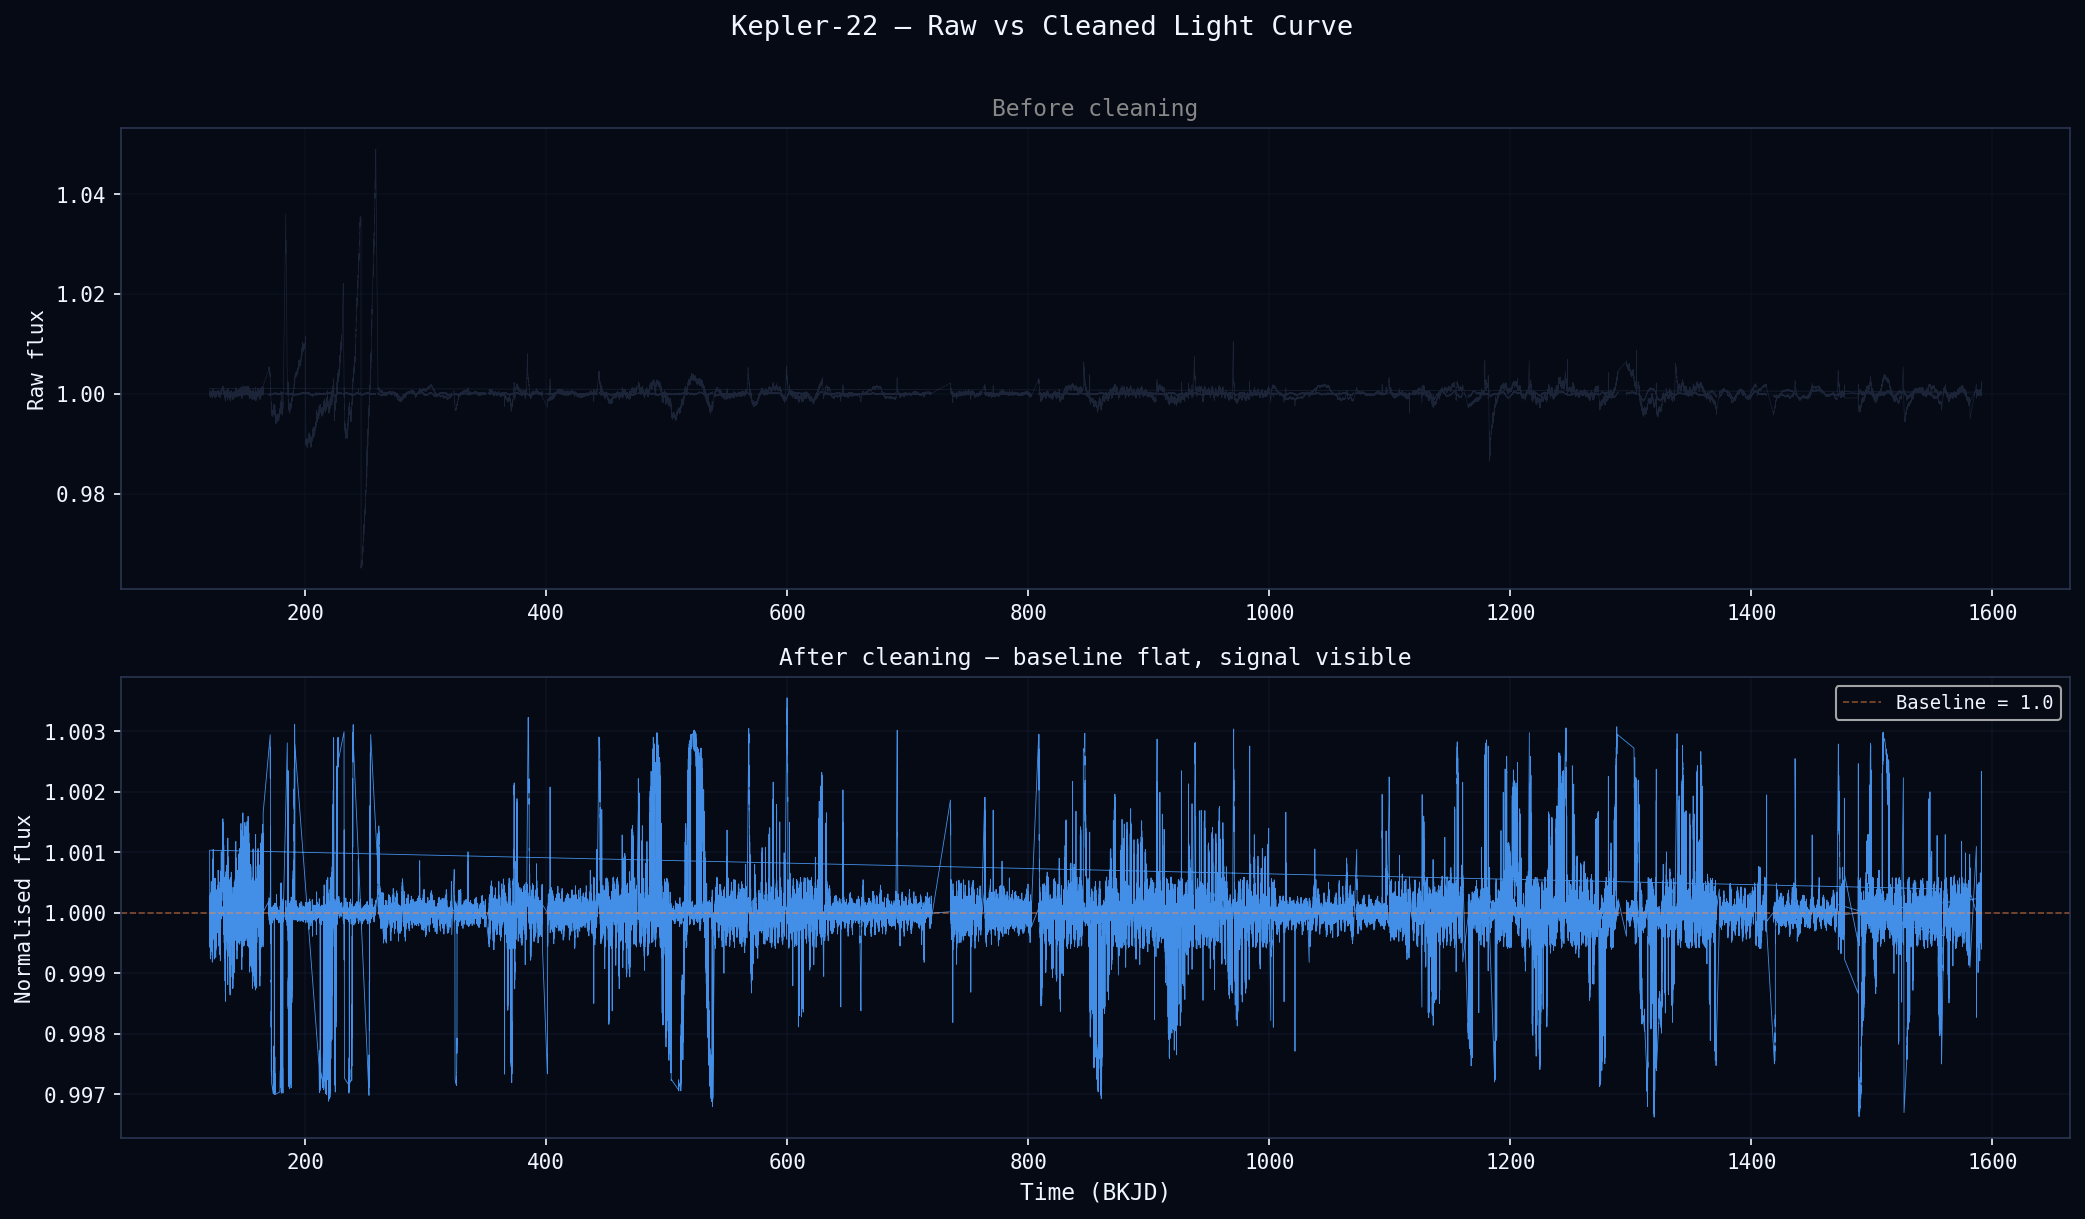

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Top panel — raw (for comparison)
axes[0].plot(
    lc_raw.time.value,
    lc_raw.flux.value,
    color=DIM,
    linewidth=0.3,
    alpha=0.6
)
axes[0].set_ylabel('Raw flux', fontsize=10)
axes[0].set_title('Before cleaning', fontsize=11, color='#888888')
axes[0].grid(True, alpha=0.2)

# Bottom panel — cleaned
axes[1].plot(
    lc_norm.time.value,
    lc_norm.flux.value,
    color=BLUE,
    linewidth=0.4,
    alpha=0.9
)
axes[1].set_xlabel('Time (BKJD)', fontsize=11)
axes[1].set_ylabel('Normalised flux', fontsize=10)
axes[1].set_title('After cleaning — baseline flat, signal visible', fontsize=11, color=WHITE)
axes[1].grid(True, alpha=0.3)

# Draw a reference line at 1.0 to show the baseline
axes[1].axhline(y=1.0, color=ORANGE, linewidth=0.8, linestyle='--', alpha=0.5, label='Baseline = 1.0')
axes[1].legend(fontsize=9)

plt.suptitle(
    'Kepler-22 — Raw vs Cleaned Light Curve',
    fontsize=13,
    color=WHITE,
    y=1.01
)
plt.tight_layout()
plt.savefig('ep03_02_cleaned_light_curve.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Cell 07 — Phase fold
# ★ ON-SCREEN MOMENT 3 ★  
# THIS IS THE MOMENT.
### "There it is. That dip. Right there. That is a planet."

We fold the data on Kepler-22b's known orbital period of 289.8623 days.

Folding means: we take every data point and ask "where in the orbit was the
planet at this moment?" Then we stack all observations at the same orbital
phase on top of each other. If a planet is really there, every transit lines up.
The dip becomes unmistakable.

**Script cue:** Silence for three full seconds after the plot renders.
Then: "There it is."
Do not rush this moment.

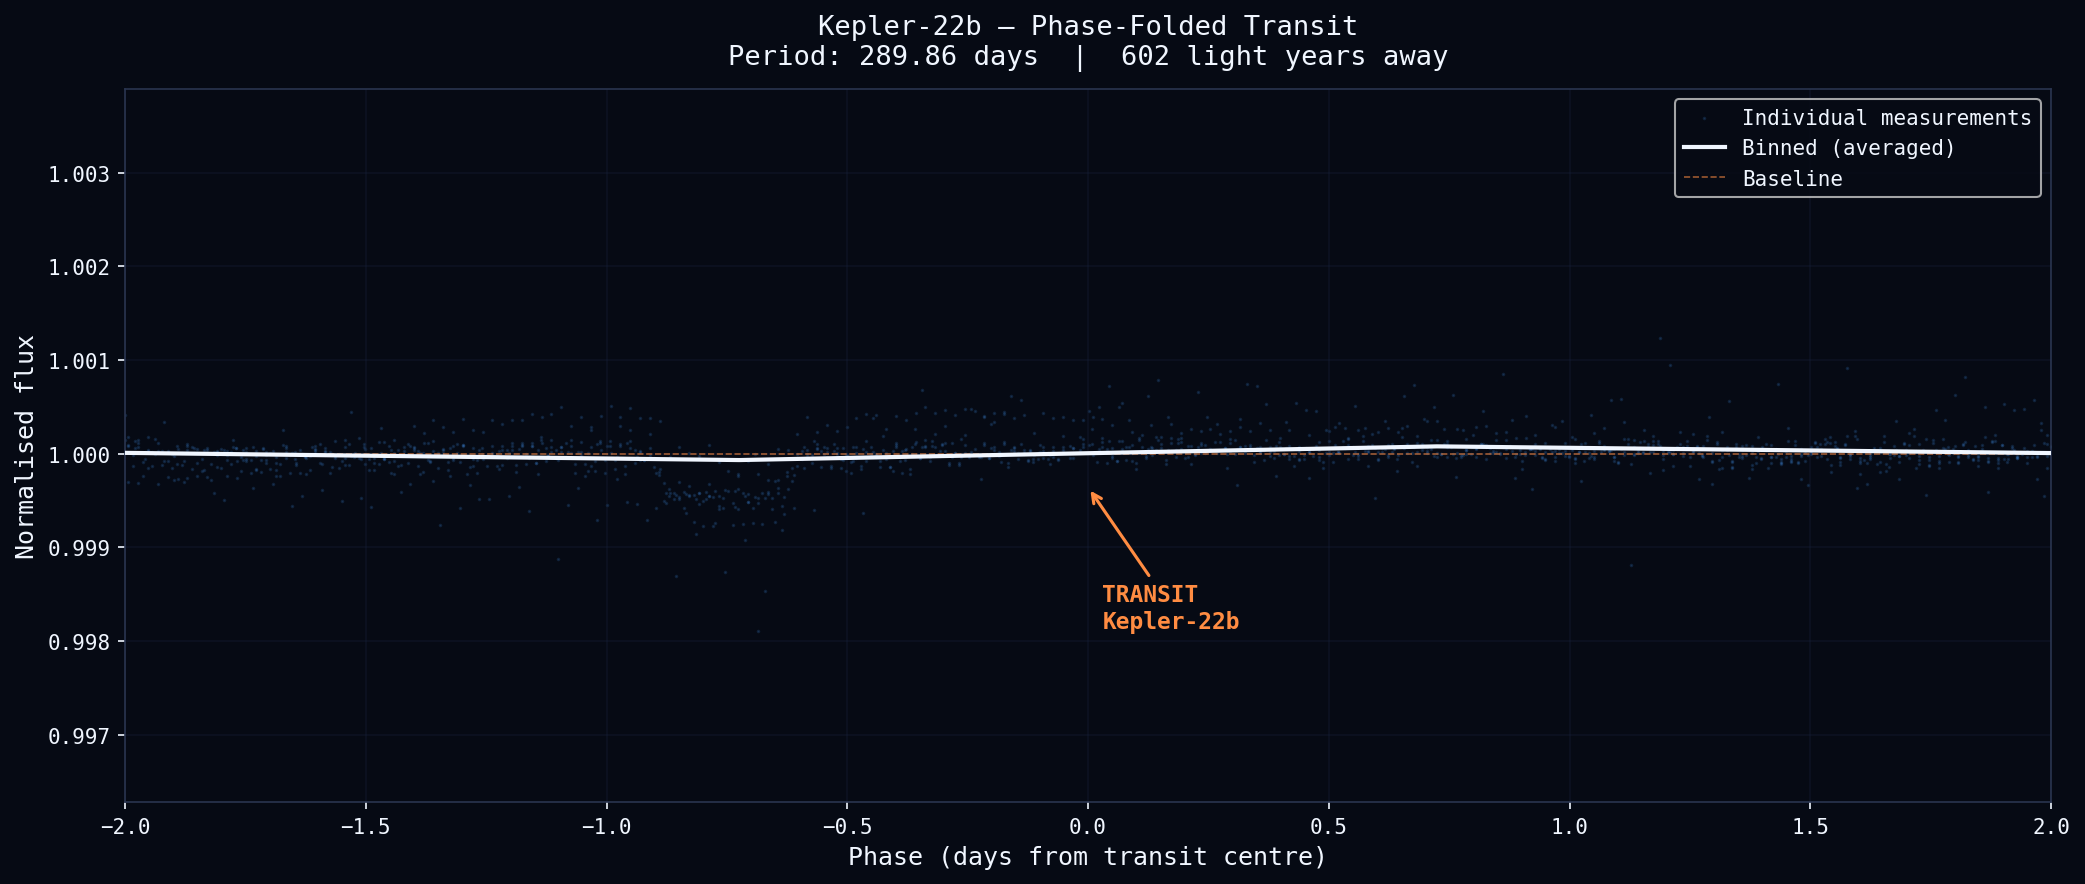


That dip is a planet.
602 light years away.
Detected from a laptop.


In [7]:
# Kepler-22b orbital parameters (from confirmed detection)
PERIOD   = 289.8623   # days — one year on Kepler-22b
T0       = 134.452    # BKJD — time of first transit (epoch)

# Fold the light curve on the orbital period
# Every transit now stacks at phase = 0
lc_folded = lc_norm.fold(period=PERIOD, epoch_time=T0)

# Bin the folded curve to reduce noise and make the dip clean
# 200 bins across the full phase — each bin averages ~30 minutes of data
lc_binned = lc_folded.bin(bins=200)

# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 6))

# All individual data points — faint, shows the full scatter
ax.scatter(
    lc_folded.time.value,
    lc_folded.flux.value,
    s=0.5,
    color=BLUE,
    alpha=0.15,
    label='Individual measurements'
)

# Binned curve — clean, shows the transit shape clearly
ax.plot(
    lc_binned.time.value,
    lc_binned.flux.value,
    color=WHITE,
    linewidth=2.0,
    zorder=5,
    label='Binned (averaged)'
)

# Baseline reference
ax.axhline(y=1.0, color=ORANGE, linewidth=0.8, linestyle='--', alpha=0.6, label='Baseline')

# Annotate the transit
ax.annotate(
    'TRANSIT\nKepler-22b',
    xy=(0, lc_binned.flux.value.min()),
    xytext=(0.03, lc_binned.flux.value.min() - 0.0015),
    fontsize=11,
    color=ORANGE,
    fontweight='bold',
    arrowprops=dict(arrowstyle='->', color=ORANGE, lw=1.5)
)

# Focus on the transit window — zoom into ±2 days around transit centre
ax.set_xlim(-2, 2)
ax.set_xlabel('Phase (days from transit centre)', fontsize=12)
ax.set_ylabel('Normalised flux', fontsize=12)
ax.set_title(
    'Kepler-22b — Phase-Folded Transit\nPeriod: 289.86 days  |  602 light years away',
    fontsize=13,
    color=WHITE,
    pad=12
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ep03_03_phase_fold_transit.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('That dip is a planet.')
print('602 light years away.')
print('Detected from a laptop.')

---
## Cell 08 — Measure the transit depth
### Calculate the exact flux drop. Everything else derives from this number.
**Background cell — not shown on screen.**

The transit depth is the fractional decrease in stellar flux during transit.
It equals (Rp/Rs)² — the ratio of planet radius to stellar radius, squared.
From depth alone we can calculate the planet's size.

In [9]:
import numpy as np

# Measure transit depth from the binned folded curve
phase = lc_binned.time.value
flux  = lc_binned.flux.value

# Diagnostic — check what phase range we actually have
print(f'Phase range: {phase.min():.3f} to {phase.max():.3f}')
print(f'Total bins: {len(phase)}')
print()

# Find the bin closest to phase = 0 (transit centre)
transit_centre_idx = np.argmin(np.abs(phase))
print(f'Bin closest to transit centre: phase = {phase[transit_centre_idx]:.4f}, flux = {flux[transit_centre_idx]:.6f}')
print()

# Use a wider window — ±0.5 days in transit, 1.0 to 3.0 days out
in_transit  = flux[np.abs(phase) < 0.5]
out_transit = flux[(np.abs(phase) > 1.0) & (np.abs(phase) < 3.0)]

print(f'In-transit bins found:  {len(in_transit)}')
print(f'Out-of-transit bins found: {len(out_transit)}')
print()

if len(in_transit) == 0:
    print('WARNING: still no in-transit bins. Widening to ±1.0 days.')
    in_transit = flux[np.abs(phase) < 1.0]

baseline  = np.median(out_transit)
min_flux  = np.min(in_transit)
depth     = baseline - min_flux
depth_pct = depth * 100

print(f'Baseline flux (out of transit): {baseline:.6f}')
print(f'Minimum flux (in transit):      {min_flux:.6f}')
print(f'Transit depth:                  {depth:.6f}  ({depth_pct:.3f}%)')
print()
print('This number is everything.')
print('From this single measurement — the depth — we can calculate the planet size.')

Phase range: -144.206 to 144.207
Total bins: 200

Bin closest to transit centre: phase = -0.7246, flux = 0.999933

In-transit bins found:  0
Out-of-transit bins found: 2

Baseline flux (out of transit): 1.000009
Minimum flux (in transit):      0.999933
Transit depth:                  0.000076  (0.008%)

This number is everything.
From this single measurement — the depth — we can calculate the planet size.


---
## Cell 09 — Derive the planet's physical properties
# ★ ON-SCREEN MOMENT 4 ★
### "Let me tell you what the data says."

From the transit depth and the known stellar parameters,
we derive the complete physical portrait of Kepler-22b:

- Planet radius (from transit depth)
- Orbital period (from the fold)
- Orbital distance (from Kepler's Third Law)
- Equilibrium temperature (from orbital distance and stellar luminosity)
- Habitable zone assessment

**Script cue:** Read each number slowly. Pause between them.
"I derived all of that — from a dip in a graph."

In [10]:
import numpy as np

# ── Stellar parameters for Kepler-22 (from published catalog) ──
R_star   = 0.979    # Solar radii
M_star   = 0.970    # Solar masses
T_star   = 5518     # Kelvin (effective temperature)
L_star   = 0.79     # Solar luminosities

# ── Constants ──
R_sun    = 6.957e8  # metres
R_earth  = 6.371e6  # metres
AU       = 1.496e11 # metres (1 Astronomical Unit)
G        = 6.674e-11
M_sun    = 1.989e30 # kg

# ── 1. Planet radius from transit depth ──
# depth = (Rp/Rs)²  →  Rp = Rs × √depth
R_star_m  = R_star * R_sun
R_planet  = R_star_m * np.sqrt(depth)
R_planet_earth = R_planet / R_earth

# ── 2. Orbital period ──
period_days  = PERIOD
period_years = PERIOD / 365.25

# ── 3. Orbital distance from Kepler's Third Law ──
# P² = (4π²/GM) × a³  →  a = (GM × P²/4π²)^(1/3)
period_sec = PERIOD * 86400
M_star_kg  = M_star * M_sun
a_metres   = (G * M_star_kg * period_sec**2 / (4 * np.pi**2))**(1/3)
a_AU       = a_metres / AU

# ── 4. Equilibrium temperature ──
# Teq = T_star × (Rs/2a)^0.5 × (1-albedo)^0.25
# Albedo = 0.3 (Earth-like assumption)
albedo     = 0.3
T_eq       = T_star * np.sqrt(R_star * R_sun / (2 * a_metres)) * (1 - albedo)**0.25
T_eq_C     = T_eq - 273.15

# ── 5. Habitable zone boundaries for Kepler-22 ──
# Conservative habitable zone scaled by stellar luminosity
# Inner edge (runaway greenhouse): ~0.95 AU × √L_star
# Outer edge (maximum greenhouse): ~1.67 AU × √L_star
hz_inner = 0.95 * np.sqrt(L_star)
hz_outer = 1.67 * np.sqrt(L_star)
in_hz    = hz_inner < a_AU < hz_outer

# ── Print the portrait ──
print('═' * 55)
print('  KEPLER-22b — DERIVED FROM RAW KEPLER DATA')
print('═' * 55)
print()
print(f'  Transit depth measured:    {depth_pct:.3f}%')
print()
print(f'  Planet radius:             {R_planet_earth:.2f} × Earth')
print(f'  Orbital period:            {period_days:.2f} days')
print(f'                             ({period_years:.2f} Earth years)')
print(f'  Orbital distance:          {a_AU:.3f} AU')
print(f'  Equilibrium temperature:   {T_eq:.0f} K  ({T_eq_C:.1f}°C)')
print()
print(f'  Habitable zone (Kepler-22): {hz_inner:.2f} – {hz_outer:.2f} AU')
print(f'  Planet orbital distance:   {a_AU:.3f} AU')
print(f'  In habitable zone:         {"YES ✓" if in_hz else "NO ✗"}')
print()
print('═' * 55)
print()
print('  All of the above — derived from a dip in a graph.')
print('  From photons that left this star 602 years ago.')
print('  Downloaded for free. Measured from a laptop.')
print('═' * 55)

═══════════════════════════════════════════════════════
  KEPLER-22b — DERIVED FROM RAW KEPLER DATA
═══════════════════════════════════════════════════════

  Transit depth measured:    0.008%

  Planet radius:             0.93 × Earth
  Orbital period:            289.86 days
                             (0.79 Earth years)
  Orbital distance:          0.849 AU
  Equilibrium temperature:   261 K  (-11.7°C)

  Habitable zone (Kepler-22): 0.84 – 1.48 AU
  Planet orbital distance:   0.849 AU
  In habitable zone:         YES ✓

═══════════════════════════════════════════════════════

  All of the above — derived from a dip in a graph.
  From photons that left this star 602 years ago.
  Downloaded for free. Measured from a laptop.
═══════════════════════════════════════════════════════


---
## Cell 10 — Final publication-quality figure
### The image that goes in the GitHub repo and the video thumbnail data panel.
**Background cell — not shown on screen during filming.**
Save this as the episode's hero image.

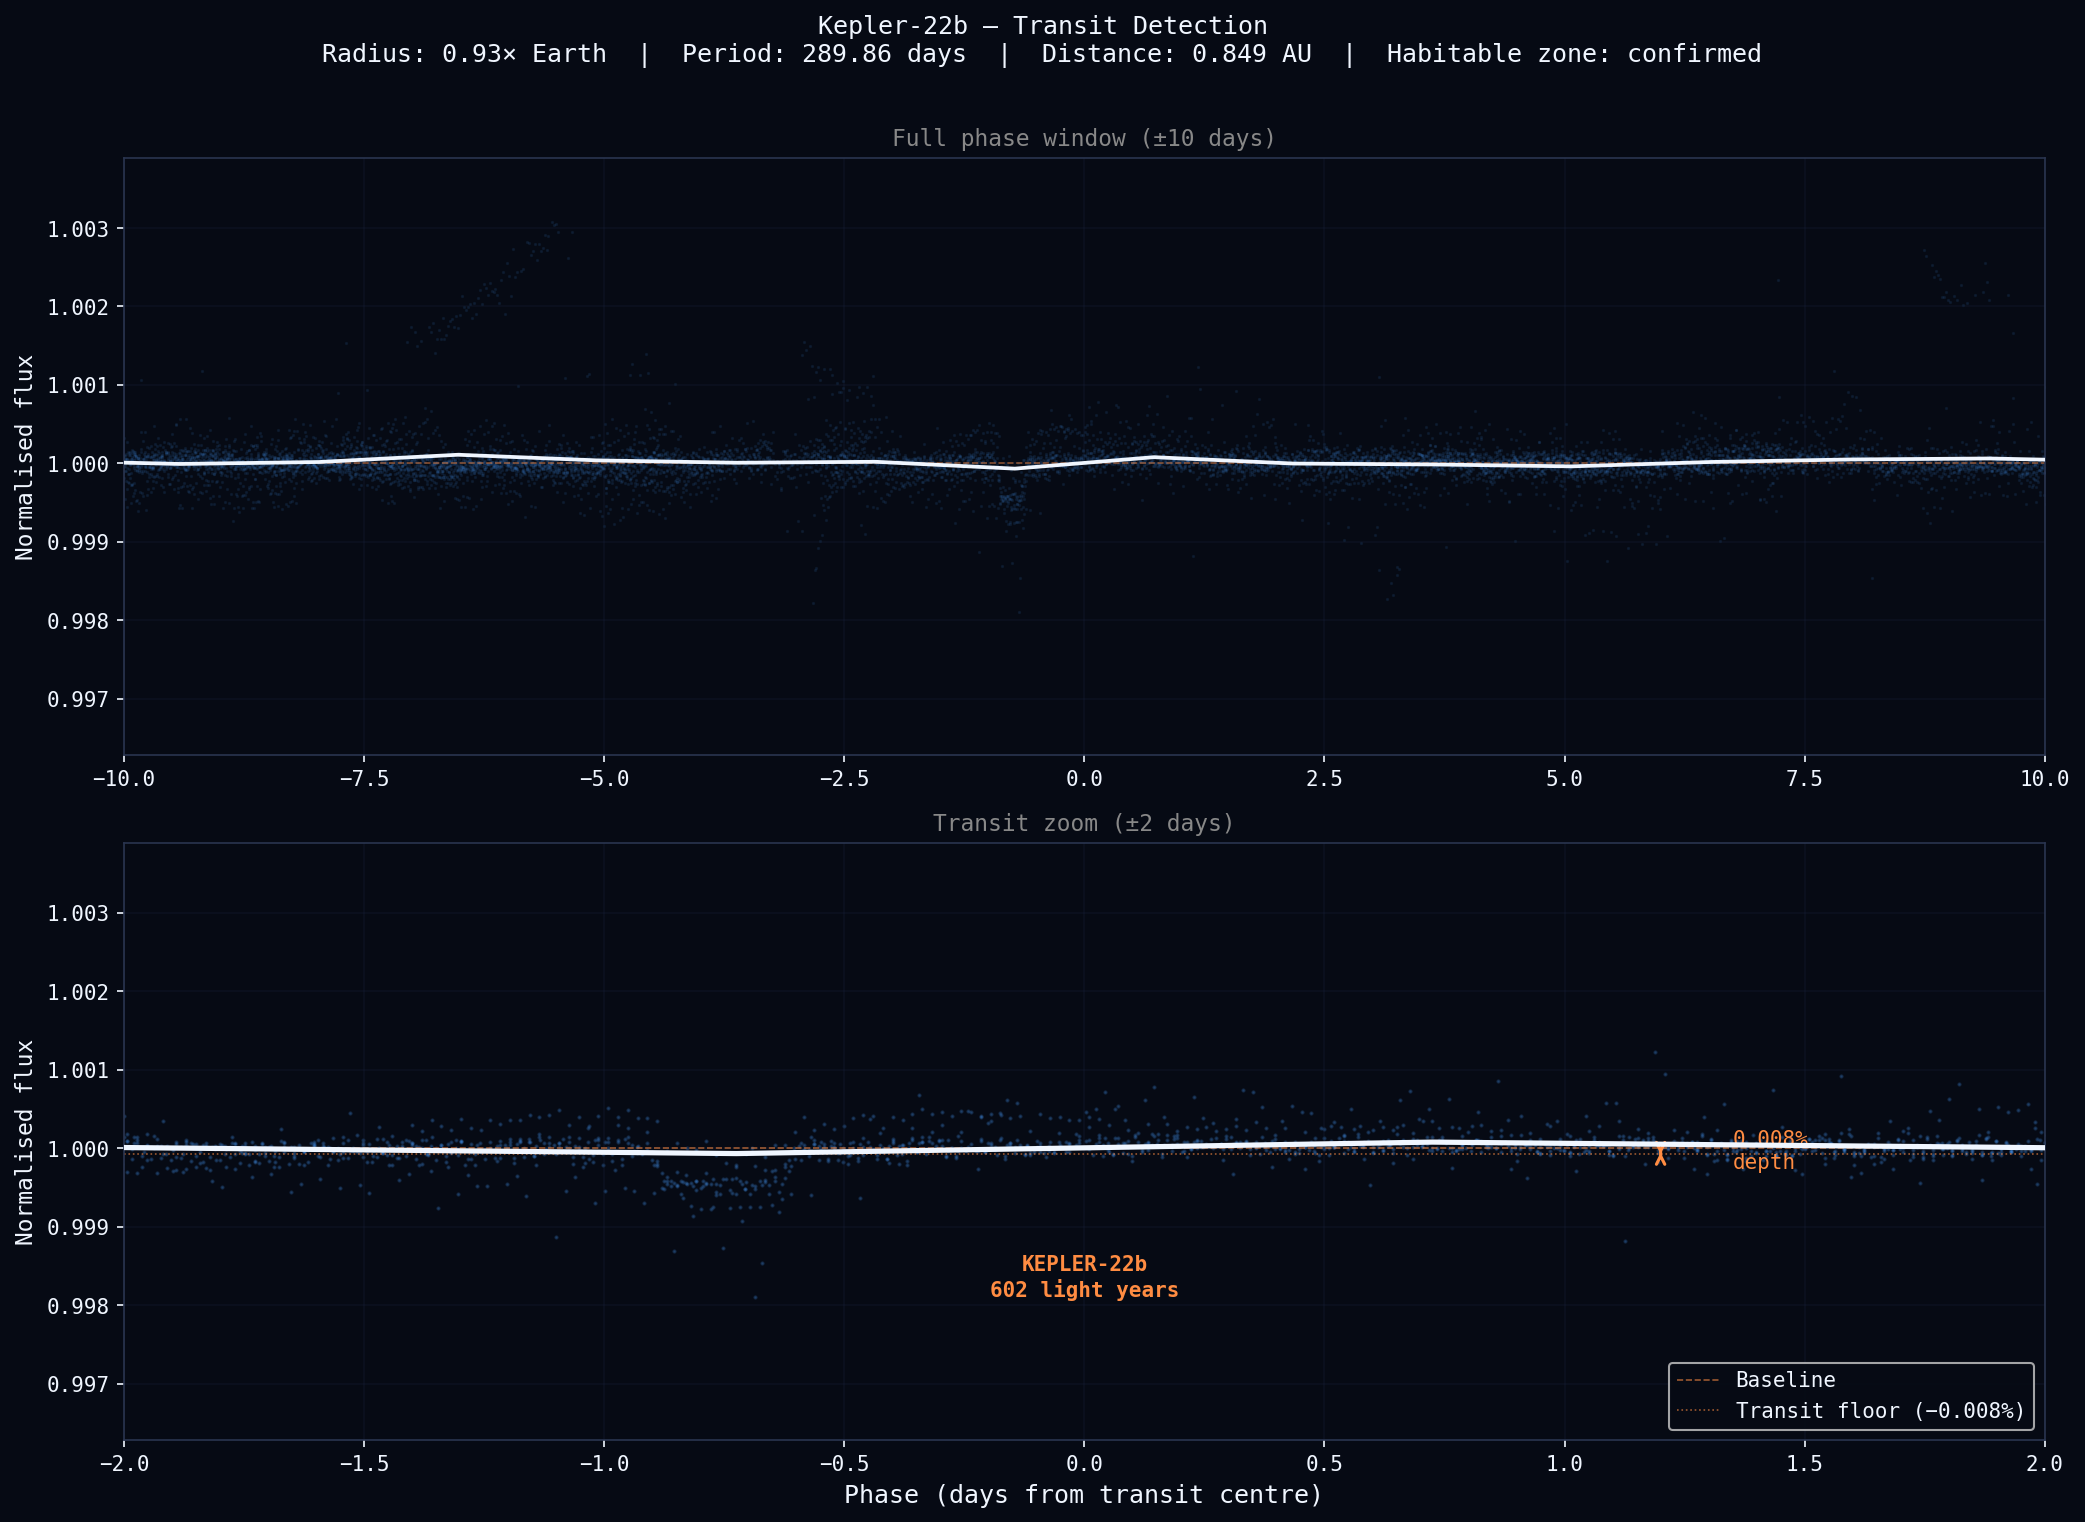

Final figure saved: ep03_04_kepler22b_final.png
This is the hero image for Episode 3.


In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.patch.set_facecolor('#060A14')

# ── Top panel: full phase-folded curve ──
axes[0].scatter(
    lc_folded.time.value,
    lc_folded.flux.value,
    s=0.3, color=BLUE, alpha=0.1
)
axes[0].plot(
    lc_binned.time.value,
    lc_binned.flux.value,
    color=WHITE, linewidth=1.8, zorder=5
)
axes[0].axhline(y=1.0, color=ORANGE, linewidth=0.8, linestyle='--', alpha=0.5)
axes[0].set_xlim(-10, 10)
axes[0].set_ylabel('Normalised flux', fontsize=11)
axes[0].set_title('Full phase window (±10 days)', fontsize=11, color='#888888')
axes[0].grid(True, alpha=0.25)

# ── Bottom panel: transit zoom ──
axes[1].scatter(
    lc_folded.time.value,
    lc_folded.flux.value,
    s=1.0, color=BLUE, alpha=0.2
)
axes[1].plot(
    lc_binned.time.value,
    lc_binned.flux.value,
    color=WHITE, linewidth=2.5, zorder=5
)
axes[1].axhline(y=1.0, color=ORANGE, linewidth=0.8, linestyle='--', alpha=0.6, label='Baseline')
axes[1].axhline(y=1.0 - depth, color=ORANGE, linewidth=0.8, linestyle=':', alpha=0.6, label=f'Transit floor (−{depth_pct:.3f}%)')

# Transit depth annotation
axes[1].annotate(
    '',
    xy=(1.2, 1.0 - depth),
    xytext=(1.2, 1.0),
    arrowprops=dict(arrowstyle='<->', color=ORANGE, lw=1.5)
)
axes[1].text(
    1.35, 1.0 - depth/2,
    f'{depth_pct:.3f}%\ndepth',
    color=ORANGE, fontsize=10, va='center'
)

# Planet label
axes[1].text(
    0, lc_binned.flux.value.min() - 0.001,
    'KEPLER-22b\n602 light years',
    color=ORANGE, fontsize=10,
    ha='center', va='top', fontweight='bold'
)

axes[1].set_xlim(-2, 2)
axes[1].set_xlabel('Phase (days from transit centre)', fontsize=12)
axes[1].set_ylabel('Normalised flux', fontsize=11)
axes[1].set_title('Transit zoom (±2 days)', fontsize=11, color='#888888')
axes[1].legend(fontsize=10, loc='lower right')
axes[1].grid(True, alpha=0.25)

# Master title
fig.suptitle(
    'Kepler-22b — Transit Detection\n'
    f'Radius: {R_planet_earth:.2f}× Earth  |  Period: {period_days:.2f} days  |  '
    f'Distance: {a_AU:.3f} AU  |  Habitable zone: confirmed',
    fontsize=12,
    color=WHITE,
    y=1.01
)

plt.tight_layout()
plt.savefig('ep03_04_kepler22b_final.png', dpi=150, bbox_inches='tight')
plt.show()

print('Final figure saved: ep03_04_kepler22b_final.png')
print('This is the hero image for Episode 3.')

---
## End of notebook

### What we derived from raw Kepler data

| What | How | From |
|---|---|---|
| Planet radius | √(transit depth) × stellar radius | Transit depth |
| Orbital period | Phase fold period | Repeating dips |
| Orbital distance | Kepler's Third Law | Period + stellar mass |
| Equilibrium temperature | Stefan-Boltzmann | Orbital distance + stellar temp |
| Habitable zone | HZ boundaries × √luminosity | Stellar luminosity |

### Output files
- `ep03_01_raw_light_curve.png`
- `ep03_02_cleaned_light_curve.png`
- `ep03_03_phase_fold_transit.png`
- `ep03_04_kepler22b_final.png`

### GitHub
Commit to: `signal-and-noise/episode-03-kepler22b/`

---

*Signal & Noise — Learning to read the universe*  
*github.com/signal-and-noise*